### Logistic Regression on Imbalanced Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 15

In [2]:
from collections import Counter
from sklearn.datasets import make_classification 

In [5]:
X, y = make_classification(n_samples=10000,
                          n_features=2,
                          n_clusters_per_class=1,
                          n_redundant=0,
                          weights=[0.99],
                          random_state=RANDOM_STATE)

In [11]:
pd.DataFrame(X).head(3)

,0,1
0,-1.897992,-0.976874
1,-0.959803,1.353039
2,0.446928,1.602003


In [14]:
pd.DataFrame(y).head(3)

,0
0,0
1,0
2,0


In [6]:
Counter(y)

Counter({np.int64(0): 9847, np.int64(1): 153})

<Axes: xlabel='0', ylabel='1'>

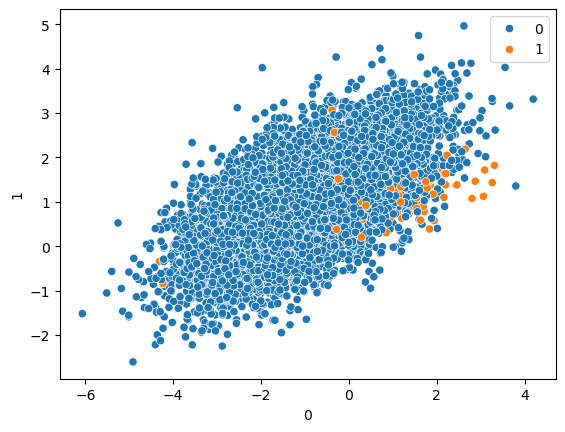

In [15]:
sns.scatterplot(data=pd.DataFrame(X), x=pd.DataFrame(X)[0],
               y=pd.DataFrame(X)[1], hue=y)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.25,
                                                   random_state=RANDOM_STATE)

In [18]:
class_weight = [
    {0:w, 1:y} 
    for w in [1, 10, 50, 100] 
    for y in [1, 10, 50, 100]
]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(n_jobs=-1)
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100,10,1.0,0.1,0.01]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight = class_weight = [
    {0:w, 1:y} 
    for w in [1, 10, 50, 100] 
    for y in [1, 10, 50, 100]
]

In [25]:
params = dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)

In [26]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [28]:
print(grid.fit(X_train, y_train))

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(n_jobs=-1),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accurac

In [29]:
grid.best_params_

{'C': 1.0, 'class_weight': {0: 50, 1: 10}, 'penalty': 'l1', 'solver': 'saga'}

In [30]:
y_pred=grid.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

score=accuracy_score(y_test, y_pred)
print("Accuracy Score =", score)
print("\n")
print("Classification Report:\n", classification_report(y_test ,y_pred))
print("Confusion Matrix:\n" ,confusion_matrix(y_test, y_pred))

Accuracy Score = 0.984


Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2460
           1       0.00      0.00      0.00        40

    accuracy                           0.98      2500
   macro avg       0.49      0.50      0.50      2500
weighted avg       0.97      0.98      0.98      2500

Confusion Matrix:
 [[2460    0]
 [  40    0]]
